# PV Production Forecasting

Questo notebook rifattorizza l'esperimento di forecasting della produzione fotovoltaica mantenendo la logica scientifica della versione stagionale.

**Pipeline:** dati grezzi -> resampling orario -> split temporale -> scaling sul solo training -> sequenze -> LSTM/GRU -> baseline `t-24h` -> valutazione stagionale.

Le celle sono progettate per essere eseguite dall'alto verso il basso dopo il riavvio del kernel.

## 01 - Environment and experiment configuration

Questa sezione raccoglie tutte le scelte modificabili. I valori iniziali preservano quelli dell'esperimento esistente: sequenze di 12, 24 e 48 ore, modelli LSTM/GRU, 32 unita ricorrenti, dropout 0.20, Adam con learning rate 0.001, clipnorm 1.0, massimo 10 epoche e batch size 64.

La gestione a chunk, `float32` e il cache locale sono ottimizzazioni operative: non cambiano il target `Pg` ne la frequenza oraria finale.

In [1]:
from pathlib import Path
from codecarbon import EmissionsTracker
import gc
import random
import time
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, GRU, Input, LSTM

# inizio registrazione delle emissioni di CO2
tracker = EmissionsTracker()
tracker.start()


# CONFIGURAZIONE DELL'ESPERIMENTO
CONFIG = {
    # Riproducibilita
    "random_seed": 42,

    # Dati e target
    "target_col": "Pg",
    "resample_rule": "1h",
    "chunk_size": 100_000,
    "dtype": "float32",
    "cache_filename": "dataset_ready.pkl",

    # Split temporale e sequenze
    "time_steps": [12, 24, 48],
    "train_ratio": 0.70,
    "validation_ratio": 0.15,
    # test = 0.15

    # Modelli principali
    "model_types": ["LSTM", "GRU"],
    "units": 32,
    "dropout": 0.20, # "spegne" casualmente il 20% dei neuroni del layer
    "learning_rate": 0.001,
    "clipnorm": 1.0, # limita Exploding Gradient
    "epochs": 10,
    "batch_size": 64, # Corregge 64 test alla volta
    "early_stopping_patience": 2, # 2 epoche senza miglioramenti 

    # Esperimento stagionale, mantenuto dalla versione esistente
    "seasonal_epochs": 5,
    "seasonal_patience": 1,
    "seasonal_time_steps": 12, # valore fisso per il modello stagionale preso dalla versione migliore esistente
    "seasonal_forecast_hours": 168,
    "seasonal_year": 2022,

    # Ipotesi energetiche ed economiche semplificate
    "training_power_w": 80.0,
    "prediction_power_w": 30.0,
    "energy_price_eur_kwh": 0.25,
    "default_inference_seconds": 10.0,
}

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "kaggle_data"
ARCHIVE_PATH = BASE_DIR / "archive.zip"

print("Configurazione caricata.")
print(f"Target: {CONFIG['target_col']} | sequenze: {CONFIG['time_steps']} | modelli: {CONFIG['model_types']}")

[codecarbon WARNING @ 09:39:03] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 09:39:03] Emissions data (if any) will be saved to file d:\PiAgent\progetto_Con_aiuto_di_PiAgent\consegnaProgetto\emissions.csv
[codecarbon INFO @ 09:39:05] [setup] RAM Tracking...
[codecarbon INFO @ 09:39:05] [setup] CPU Tracking...
[codecarbon INFO @ 09:39:05] [setup] GPU Tracking...
[codecarbon INFO @ 09:39:05] Tracking Nvidia GPUs via PyNVML
[codecarbon WARNING @ 09:39:07] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: CPU power reading via the Energy Meter Interface requires Windows 11 on bare metal (not a VM)

[codecarbon INFO @ 09:39:07] CPU Model on constant consumption mode: Intel(R) Core(TM) i7-8700 CPU @ 3.20GHz
[codecarbon WARNING @ 09:39:07] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 09:39:07] The below tracking methods have been set up:
                RAM Tracking M

Configurazione caricata.
Target: Pg | sequenze: [12, 24, 48] | modelli: ['LSTM', 'GRU']


In [2]:
def show_configuration(config):
    sections = {
        "PARAMETRI DATI": ["target_col", "resample_rule", "chunk_size", "dtype"],
        "PARAMETRI MODELLO": ["model_types", "units", "dropout", "time_steps"],
        "PARAMETRI ADDESTRAMENTO": ["learning_rate", "clipnorm", "batch_size", "epochs", "early_stopping_patience"],
        "PARAMETRI VALUTAZIONE": ["train_ratio", "validation_ratio", "seasonal_time_steps", "seasonal_forecast_hours"],
        "PARAMETRI ENERGETICI": ["training_power_w", "prediction_power_w", "energy_price_eur_kwh"],
    }
    for title, keys in sections.items():
        print(f"\n{title}\n" + "-" * len(title))
        for key in keys:
            print(f"{key}: {config[key]}")


show_configuration(CONFIG)


PARAMETRI DATI
--------------
target_col: Pg
resample_rule: 1h
chunk_size: 100000
dtype: float32

PARAMETRI MODELLO
-----------------
model_types: ['LSTM', 'GRU']
units: 32
dropout: 0.2
time_steps: [12, 24, 48]

PARAMETRI ADDESTRAMENTO
-----------------------
learning_rate: 0.001
clipnorm: 1.0
batch_size: 64
epochs: 10
early_stopping_patience: 2

PARAMETRI VALUTAZIONE
---------------------
train_ratio: 0.7
validation_ratio: 0.15
seasonal_time_steps: 12
seasonal_forecast_hours: 168

PARAMETRI ENERGETICI
--------------------
training_power_w: 80.0
prediction_power_w: 30.0
energy_price_eur_kwh: 0.25


### Riepilogo configurazione

Questa cella mostra i valori effettivamente usati dall'esperimento. Per cambiare sequenze, modelli, training o assunzioni economiche si modifica soltanto `CONFIG`.

In [3]:
# 02 - Configurazione e metadati del dataset


def extract_dataset(archive_path, data_dir):
    """Estrae l'archivio locale e restituisce i percorsi stabili di dt1 e dt2."""
    data_dir.mkdir(exist_ok=True)
    if not archive_path.exists():
        raise FileNotFoundError(f"Archivio non trovato: {archive_path}")

    with zipfile.ZipFile(archive_path, "r") as archive:
        archive.extractall(data_dir)

    dt1_file = next(data_dir.glob("dt1*.csv"), None)
    dt2_file = next(data_dir.glob("dt2*.csv"), None)
    if dt1_file is None or dt2_file is None:
        raise FileNotFoundError("Lo ZIP deve contenere un file dt1 e un file dt2.")

    expected_dt1 = data_dir / "dt1_solar_and_meteorological_measurement.csv"
    expected_dt2 = data_dir / "dt2_electrical_production_inverter_1_with_faults.csv"
    if dt1_file != expected_dt1:
        dt1_file.replace(expected_dt1)
    if dt2_file != expected_dt2:
        dt2_file.replace(expected_dt2)
    return expected_dt1, expected_dt2


def get_dataset_metadata(file_path, time_col="time"):
    """Legge solo i timestamp per trovare l'inizio temporale comune."""
    timestamps = pd.read_csv(file_path, usecols=[time_col])[time_col]
    return (
        pd.to_datetime(timestamps.iloc[0], utc=True),
        pd.to_datetime(timestamps.iloc[-1], utc=True),
        len(timestamps),
    )


path_meteo, path_prod = extract_dataset(ARCHIVE_PATH, DATA_DIR)
metadata_meteo = get_dataset_metadata(path_meteo)
metadata_prod = get_dataset_metadata(path_prod)
consistent_start = max(metadata_meteo[0], metadata_prod[0])
print(f"Inizio comune: {consistent_start}")
print(f"Righe meteo: {metadata_meteo[2]:,} | righe produzione: {metadata_prod[2]:,}")

[codecarbon INFO @ 09:39:22] Energy consumed for RAM : 0.000084 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 09:39:22] Energy consumed for all GPUs : 0.000152 kWh. Total GPU Power : 36.35938352381605 W
[codecarbon INFO @ 09:39:22] Delta energy consumed for CPU with cpu_load : 0.000031 kWh, power : 7.3424000000000005 W
[codecarbon INFO @ 09:39:22] Energy consumed for All CPU : 0.000031 kWh
[codecarbon INFO @ 09:39:22] 0.000267 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 09:39:37] Energy consumed for RAM : 0.000167 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 09:39:37] Energy consumed for all GPUs : 0.000269 kWh. Total GPU Power : 27.932478864257103 W
[codecarbon INFO @ 09:39:37] Delta energy consumed for CPU with cpu_load : 0.000028 kWh, power : 6.6177545585937505 W
[codecarbon INFO @ 09:39:37] Energy consumed for All CPU : 0.000058 kWh
[codecarbon INFO @ 09:39:37] 0.000494 kWh of electricity and 0.000000 L of water were used since the beginn

Inizio comune: 2021-10-28 12:37:45+00:00
Righe meteo: 45,123,826 | righe produzione: 2,988,814


## 02 - Dataset setup

**Input:** `archive.zip` locale con produzione e misure meteorologiche.

**Output:** percorsi verificati, timestamp UTC e istante comune di inizio. Leggiamo inizialmente solo `time` per evitare di caricare inutilmente i CSV completi.

## 03 - Caricamento, resampling e cache

Questa fase trasforma i CSV ad alta frequenza nel dataset orario usato dall'esperimento.

**Input:** file di produzione e misure meteorologiche.

**Output:** `ds_all_full`, con target `Pg` e feature meteorologiche allineate su timestamp UTC.

> ### Perché questa ottimizzazione?
>
> I file vengono letti a blocchi, filtrati prima del resampling e convertiti a `float32`. Il risultato orario viene memorizzato in cache per evitare di ripetere il preprocessing.
>
> **Trade-off:** il primo caricamento richiede il resampling; le esecuzioni successive risparmiano tempo e RAM.

In [4]:
# 03 - Caricamento ottimizzato e resampling orario


def load_and_resample(file_path, start_date, config, columns=None):
    """Legge, filtra, ricampiona e riduce un CSV senza caricare tutto in memoria."""
    partial_frames = []
    reader = pd.read_csv(
        file_path,
        usecols=columns,
        parse_dates=["time"],
        chunksize=config["chunk_size"],
    )
    for chunk in reader:
        chunk["time"] = pd.to_datetime(chunk["time"], utc=True)
        chunk = chunk.loc[chunk["time"] >= start_date]
        if chunk.empty:
            del chunk
            continue
        numeric_columns = chunk.select_dtypes(include=["number"]).columns
        chunk[numeric_columns] = chunk[numeric_columns].astype(config["dtype"])
        partial_frames.append(
            chunk.set_index("time").resample(config["resample_rule"]).mean()
        )
        del chunk
        gc.collect()

    if not partial_frames:
        raise ValueError(f"Nessun dato disponibile dopo {start_date}: {file_path}")
    return (
        pd.concat(partial_frames)
        .resample(config["resample_rule"])
        .mean()
        .astype(config["dtype"])
    )


def validate_cached_dataset(dataset, config):
    """Rifiuta una cache incompatibile prima di usarla nell'esperimento."""
    if config["target_col"] not in dataset.columns:
        raise ValueError("La cache non contiene il target configurato.")
    if not dataset.index.is_monotonic_increasing or dataset.index.has_duplicates:
        raise ValueError("L'indice della cache deve essere ordinato e senza duplicati.")
    if dataset.empty:
        raise ValueError("La cache del dataset e vuota.")
    return dataset.astype(config["dtype"])


def prepare_hourly_dataset(path_prod, path_meteo, start_date, config):
    """Costruisce il dataset orario unito di produzione e meteo."""
    cache_path = DATA_DIR / config["cache_filename"]
    if cache_path.exists():
        cached = pd.read_pickle(cache_path)
        cached.index = pd.to_datetime(cached.index, utc=True)
        return validate_cached_dataset(cached, config)

    production = load_and_resample(
        path_prod, start_date, config, columns=["time", config["target_col"]]
    ).fillna(0)
    weather = load_and_resample(path_meteo, start_date, config).interpolate(method="time")
    dataset = production.join(weather, how="inner").astype(config["dtype"])
    dataset.to_pickle(cache_path)
    del production, weather
    gc.collect()
    return validate_cached_dataset(dataset, config)


ds_all_full = prepare_hourly_dataset(path_prod, path_meteo, consistent_start, CONFIG)
print(f"Forma dataset: {ds_all_full.shape}")
print(f"RAM dataset: {ds_all_full.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
display(ds_all_full.head())

Forma dataset: (12770, 5)
RAM dataset: 0.34 MB


,Pg,DTI,GTI,TA,TPV
time,,,,,
2021-10-28 12:00:00+00:00,229.28688,153.740677,207.027267,27.174120,31.268097
2021-10-28 13:00:00+00:00,0.00000,55.520519,70.598709,25.906918,26.737392
2021-10-28 14:00:00+00:00,0.00000,5.071958,5.719972,23.883808,22.123344
2021-10-28 15:00:00+00:00,0.00000,1.342000,1.389939,23.580566,23.091074
2021-10-28 16:00:00+00:00,0.00000,2.021759,2.766986,22.512491,21.835510


### Perché questa ottimizzazione?

> **Strategia RAM:** i CSV vengono letti a blocchi, filtrati subito sulla data e ridotti a frequenza oraria prima del merge. I valori numerici vengono convertiti a `float32`; gli oggetti temporanei vengono rilasciati con garbage collection.
>
> Il dataset orario viene salvato in cache per evitare di ripetere il preprocessing nelle esecuzioni successive.

In [5]:
# 04 - Varianti del Dataset per comparazione stagionale

def build_dataset_variants(dataset, target_col):
    half_index = len(dataset) // 2
    production_full = dataset[[target_col]].copy()
    return {
        "Produzione - Full": production_full,
        "Produzione - Meta": production_full.iloc[:half_index],
        "Produzione + Meteo - Full": dataset,
        "Produzione + Meteo - Meta": dataset.iloc[:half_index],
    }


dataset_versions = build_dataset_variants(ds_all_full, CONFIG["target_col"])
for name, frame in dataset_versions.items():
    print(f"{name}: {frame.shape}")

Produzione - Full: (12770, 1)
Produzione - Meta: (6385, 1)
Produzione + Meteo - Full: (12770, 5)
Produzione + Meteo - Meta: (6385, 5)


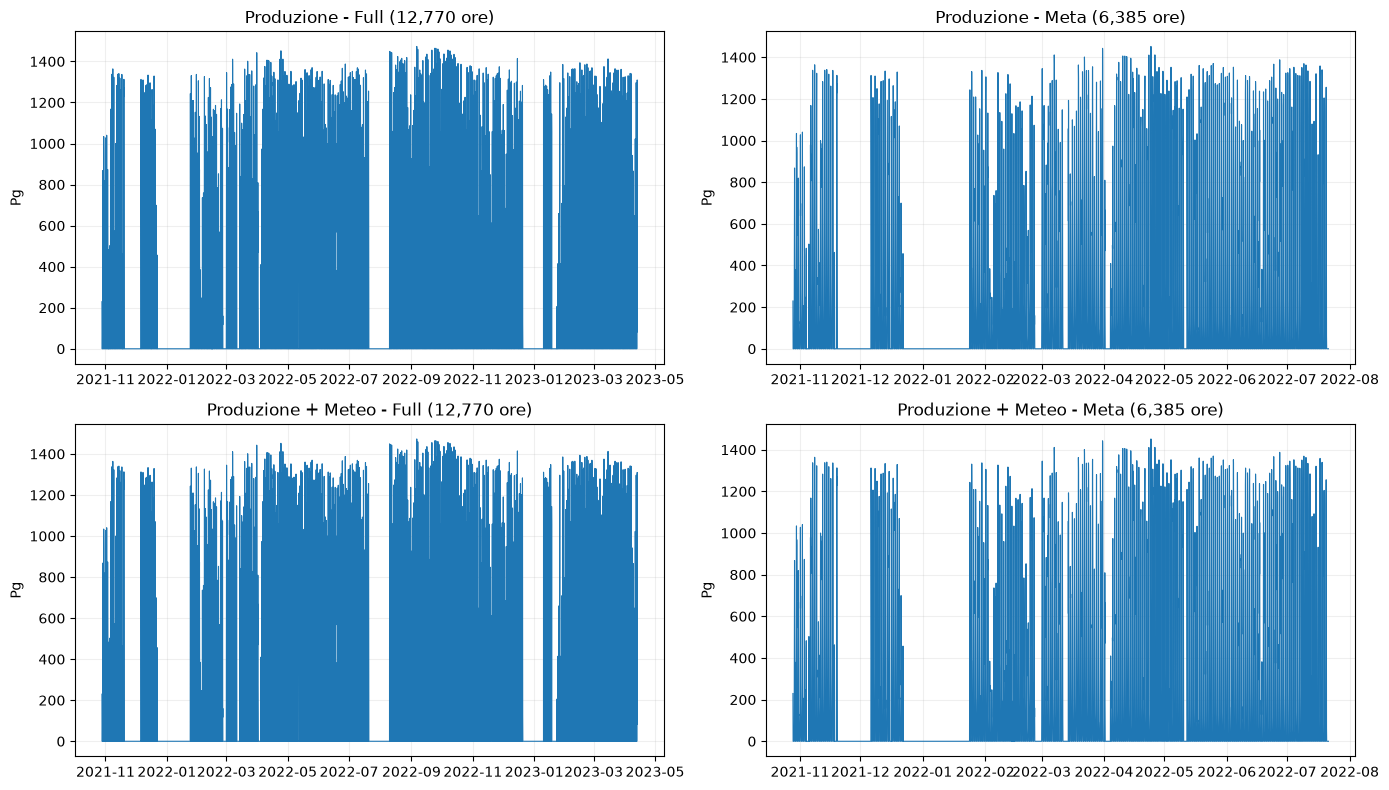

Colonne: ['Pg', 'DTI', 'GTI', 'TA', 'TPV']


In [6]:
# 05 - Panoramica del dataset

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
for axis, (name, frame) in zip(axes.flat, dataset_versions.items()):
    axis.plot(frame[CONFIG["target_col"]], linewidth=0.8)
    axis.set_title(f"{name} ({len(frame):,} ore)")
    axis.set_ylabel(CONFIG["target_col"])
    axis.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()
plt.close(fig)
print(f"Colonne: {ds_all_full.columns.tolist()}")

## 06 - Riproducibilità, sequenze e factory dei modelli

Questa sezione prepara gli oggetti condivisi dal training.

- `Pg` è il target;
- le altre colonne sono feature meteorologiche nel confronto principale;
- lo split resta cronologico 70% / 15% / 15%;
- gli scaler vengono addestrati soltanto sul prefisso di training;
- `WindowSequence` genera un batch alla volta;
- `build_model` costruisce esclusivamente LSTM o GRU.

> ### Nota sulla memoria
>
> Le finestre di validation e test non vengono materializzate tutte insieme. Questo riduce le copie intermedie senza cambiare l'ordine temporale o il target delle sequenze.

In [7]:
# 06 - Riproducibilità, generazione sequenze e factory dei modelli

def set_reproducibility(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


set_reproducibility(CONFIG["random_seed"])


class WindowSequence(tf.keras.utils.Sequence):
    """Genera finestre scalate on demand, evitando la materializzazione completa di X/y."""

    def __init__(self, data, starts, feature_indices, target_idx, scaler_x, scaler_y, time_steps, batch_size, **kwargs):
        super().__init__(**kwargs)
        self.data = data
        self.starts = np.asarray(starts, dtype=np.int64)
        self.feature_indices = feature_indices
        self.target_idx = target_idx
        self.scaler_x = scaler_x
        self.scaler_y = scaler_y
        self.time_steps = time_steps
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.starts) / self.batch_size))

    def __getitem__(self, batch_index):
        starts = self.starts[batch_index * self.batch_size:(batch_index + 1) * self.batch_size]
        features = [
            self.scaler_x.transform(self.data[start:start + self.time_steps, self.feature_indices])
            for start in starts
        ]
        targets = [
            self.scaler_y.transform(self.data[start + self.time_steps, self.target_idx].reshape(1, -1))[0]
            for start in starts
        ]
        return np.asarray(features, dtype=CONFIG["dtype"]), np.asarray(targets, dtype=CONFIG["dtype"])


def build_model(model_type, input_shape, config, seasonal=False):
    """Costruisce l'architettura single-layer LSTM o GRU esistente."""
    recurrent_layer = LSTM if model_type == "LSTM" else GRU
    dropout = config["dropout"] if not seasonal else 0.0
    model = Sequential([
        Input(shape=input_shape),
        recurrent_layer(config["units"]),
        Dropout(dropout),
        Dense(1),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=config["learning_rate"], clipnorm=config["clipnorm"]
        ),
        loss="mse",
        metrics=["mae"],
    )
    return model


def temporal_starts(n_rows, time_steps, train_ratio, validation_ratio):
    train_end = int(n_rows * train_ratio)
    validation_end = int(n_rows * (train_ratio + validation_ratio))
    return (
        np.arange(0, train_end - time_steps),
        np.arange(train_end - time_steps, validation_end - time_steps),
        np.arange(validation_end - time_steps, n_rows - time_steps),
    )


def prepare_experiment(frame, time_steps, config):
    """Adatta gli scaler solo sul training e crea finestre lazy train/validation/test."""
    data = frame.to_numpy(dtype=config["dtype"])
    target_idx = frame.columns.get_loc(config["target_col"])
    feature_indices = [index for index in range(data.shape[1]) if index != target_idx]
    train_end = int(len(data) * config["train_ratio"])
    validation_end = int(len(data) * (config["train_ratio"] + config["validation_ratio"]))
    scaler_x = MinMaxScaler().fit(data[:train_end, feature_indices])
    scaler_y = MinMaxScaler().fit(data[:train_end, target_idx].reshape(-1, 1))
    starts = temporal_starts(len(data), time_steps, config["train_ratio"], config["validation_ratio"])
    sequences = tuple(
        WindowSequence(data, split_starts, feature_indices, target_idx, scaler_x, scaler_y, time_steps, config["batch_size"])
        for split_starts in starts
    )
    return {
        "data": data,
        "target_idx": target_idx,
        "feature_indices": feature_indices,
        "scaler_y": scaler_y,
        "train_end": train_end,
        "validation_end": validation_end,
        "train": sequences[0],
        "validation": sequences[1],
        "test": sequences[2],
    }


print("Riproducibilità configurata; le finestre di sequenza verranno generate on demand.")

Riproducibilità configurata; le finestre di sequenza verranno generate on demand.


In [8]:
def audit_temporal_experiment(frame, config):
    """Verifica il protocollo temporale configurato prima del training dei modelli."""
    if config["target_col"] not in frame.columns:
        raise AssertionError(f"Colonna target mancante: {config['target_col']}")
    if not np.isclose(config["train_ratio"] + config["validation_ratio"], 0.85):
        raise AssertionError("I ratio train e validation devono lasciare il 15% per il test.")
    if config["resample_rule"] != "1h":
        raise AssertionError("L'esperimento richiede il resampling orario.")

    split_starts = temporal_starts(
        len(frame),
        max(config["time_steps"]),
        config["train_ratio"],
        config["validation_ratio"],
    )
    train_starts, validation_starts, test_starts = split_starts
    if not (
        train_starts[-1] < validation_starts[0]
        and validation_starts[-1] < test_starts[0]
    ):
        raise AssertionError("Le partizioni delle sequenze non sono cronologiche.")

    train_end = int(len(frame) * config["train_ratio"])
    validation_end = int(len(frame) * (config["train_ratio"] + config["validation_ratio"]))
    if train_end >= validation_end or validation_end >= len(frame):
        raise AssertionError("Confini dello split temporale non validi.")

    print("Audit temporale superato: target, regola oraria, split 70/15/15 e ordine delle sequenze sono validi.")
    return {
        "train_rows": train_end,
        "validation_rows": validation_end - train_end,
        "test_rows": len(frame) - validation_end,
        "max_sequence_hours": max(config["time_steps"]),
    }


temporal_audit = audit_temporal_experiment(ds_all_full, CONFIG)
temporal_audit

Audit temporale superato: target, regola oraria, split 70/15/15 e ordine delle sequenze sono validi.


{'train_rows': 8939,
 'validation_rows': 1915,
 'test_rows': 1916,
 'max_sequence_hours': 48}

## 06 - Features, split temporale e generazione sequenze

`Pg` è il target. Le altre colonne sono feature meteorologiche nel confronto principale; nelle varianti production-only viene usata soltanto la storia di `Pg`.

Lo split è temporale 70% / 15% / 15%. Gli scaler vengono fittati solo sul prefisso di training e `WindowSequence` genera un batch alla volta, preservando ordine temporale e memoria.

## 07 - Esperimento principale

Il training confronta tutte le combinazioni configurate di architettura e lunghezza della finestra. Le finestre vengono generate on demand; validation e test non vengono duplicati in memoria come grandi array intermedi.

> ### OTTIMIZZAZIONE RAM
>
> `WindowSequence` materializza solo il batch richiesto. Gli scaler sono fittati esclusivamente sul training prefix, quindi la riduzione RAM non introduce contaminazione dei dati.

## 07 - Esperimento principale e risultati

Il ciclo di training esegue tutte le combinazioni definite in `CONFIG`:

- LSTM e GRU;
- finestre da 12, 24 e 48 ore;
- stesso dataset e stesso split temporale.

**Input:** dataset orario, configurazione e generatori lazy.

**Output:** tabella con MSE, MAE, RMSE e tempo di training, oltre alle predizioni necessarie per il confronto finale.

> ### Scelta metodologica
>
> Il modello migliore viene scelto tramite RMSE sul test set. Validation e test restano separati dal fit degli scaler e il training non usa shuffle casuale.

In [9]:
def collect_predictions(model, sequence, scaler_y):
    predictions = model.predict(sequence, verbose=0).reshape(-1, 1) # Calcolo della predizione sulle finestre 12 24 48
    actual = np.concatenate([batch_y for _, batch_y in sequence], axis=0).reshape(-1, 1)
    return scaler_y.inverse_transform(actual).reshape(-1), scaler_y.inverse_transform(predictions).reshape(-1)


def calculate_metrics(actual, predicted):
    mse = float(mean_squared_error(actual, predicted))
    return {
        "MSE": mse,
        "MAE": float(mean_absolute_error(actual, predicted)),
        "RMSE": float(np.sqrt(mse)),
    }


results = []
trained_models_storage = {}
histories = {}
experiment_bundles = {}

for time_steps in CONFIG["time_steps"]:
    for model_type in CONFIG["model_types"]:
        print(f"Addestramento {model_type}, sequenza {time_steps}h...")
        bundle = prepare_experiment(ds_all_full, time_steps, CONFIG)
        model = build_model(
            model_type,
            (time_steps, len(bundle["feature_indices"])), # LE 2 DIMENSIONI DELL'INPUT (Time Steps, Features)
            CONFIG,
        )
        start_time = time.perf_counter()
        history = model.fit(
            bundle["train"],
            validation_data=bundle["validation"],
            epochs=CONFIG["epochs"],
            verbose=1,
            callbacks=[EarlyStopping(
                patience=CONFIG["early_stopping_patience"],
                restore_best_weights=True,
            )],
        )
        duration = time.perf_counter() - start_time
        val_actual, val_predicted = collect_predictions(model, bundle["validation"], bundle["scaler_y"])
        test_actual, test_predicted = collect_predictions(model, bundle["test"], bundle["scaler_y"])
        metrics = calculate_metrics(test_actual, test_predicted)
        key = f"All_{time_steps}h_{model_type}"
        results.append({
            "Modello": model_type,
            "Seq length (h)": time_steps,
            **metrics,
            "Tempo (s)": duration,
        })
        trained_models_storage[key] = {
            "val_real": val_actual,
            "val_pred": val_predicted,
            "y_real": test_actual,
            "y_pred": test_predicted,
            "time_steps": time_steps,
            "model_type": model_type,
        }
        histories[key] = history.history
        experiment_bundles[key] = bundle
        tf.keras.backend.clear_session()

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df.round(3))

Addestramento LSTM, sequenza 12h...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 0.0584 - mae: 0.1775 - val_loss: 0.0385 - val_mae: 0.1464
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0363 - mae: 0.1381 - val_loss: 0.0336 - val_mae: 0.1268
Epoch 3/10
 17/140 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0343 - mae: 0.1280

[codecarbon INFO @ 09:40:22] Energy consumed for RAM : 0.000417 kWh. RAM Power : 20.0 W


 19/140 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0339 - mae: 0.1281

[codecarbon INFO @ 09:40:22] Energy consumed for all GPUs : 0.000599 kWh. Total GPU Power : 26.76322146816558 W
[codecarbon INFO @ 09:40:22] Delta energy consumed for CPU with cpu_load : 0.000045 kWh, power : 10.7190149885 W
[codecarbon INFO @ 09:40:22] Energy consumed for All CPU : 0.000159 kWh
[codecarbon INFO @ 09:40:22] 0.001175 kWh of electricity and 0.000000 L of water were used since the beginning.


140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0321 - mae: 0.1233 - val_loss: 0.0379 - val_mae: 0.1268
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0302 - mae: 0.1160 - val_loss: 0.0310 - val_mae: 0.1138
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0296 - mae: 0.1136 - val_loss: 0.0307 - val_mae: 0.1105
Epoch 6/10
112/140 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0289 - mae: 0.1093

...

[codecarbon INFO @ 09:43:37] Energy consumed for RAM : 0.001497 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 09:43:37] Energy consumed for all GPUs : 0.002058 kWh. Total GPU Power : 31.152974027340495 W
[codecarbon INFO @ 09:43:37] Delta energy consumed for CPU with cpu_load : 0.000028 kWh, power : 6.867796150718751 W
[codecarbon INFO @ 09:43:37] Energy consumed for All CPU : 0.000555 kWh
[codecarbon INFO @ 09:43:37] 0.004110 kWh of electricity and 0.000000 L of water were used since the beginning.


139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0302 - mae: 0.1148 - val_loss: 0.0321 - val_mae: 0.1154
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0283 - mae: 0.1084 - val_loss: 0.0308 - val_mae: 0.1148
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0283 - mae: 0.1076

[codecarbon INFO @ 09:43:52] Energy consumed for RAM : 0.001581 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 09:43:52] Energy consumed for all GPUs : 0.002167 kWh. Total GPU Power : 26.113930202769684 W
[codecarbon INFO @ 09:43:52] Delta energy consumed for CPU with cpu_load : 0.000028 kWh, power : 6.780238604750001 W
[codecarbon INFO @ 09:43:52] Energy consumed for All CPU : 0.000583 kWh
[codecarbon INFO @ 09:43:52] 0.004331 kWh of electricity and 0.000000 L of water were used since the beginning.


139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0283 - mae: 0.1076 - val_loss: 0.0323 - val_mae: 0.1101
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0275 - mae: 0.1037 - val_loss: 0.0320 - val_mae: 0.1197


,Modello,Seq length (h),MSE,MAE,RMSE,Tempo (s)
0,LSTM,12,37469.863,125.572,193.571,44.156
1,GRU,12,42118.281,140.061,205.227,23.746
2,GRU,24,45521.676,139.070,213.358,47.680
3,LSTM,24,45640.254,139.283,213.636,32.056
4,LSTM,48,47516.660,154.310,217.983,26.622
5,GRU,48,51786.613,152.231,227.567,33.683


## 08 - Risultati e model selection

Il criterio di selezione resta **RMSE sul test set**. La tabella riporta anche MAE, MSE e tempo di training per rendere il confronto auditabile.

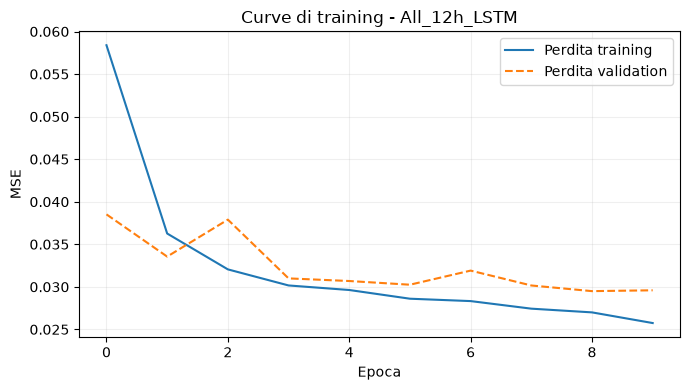

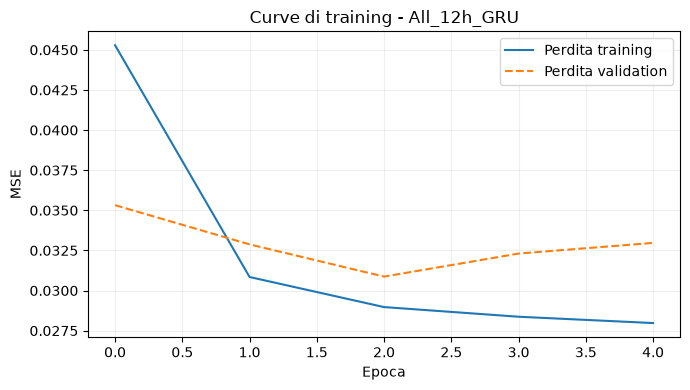

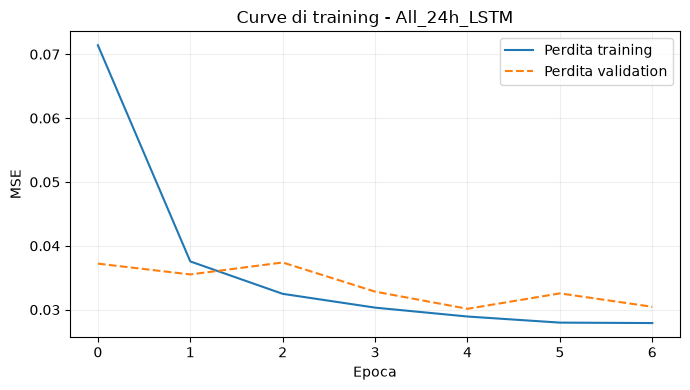

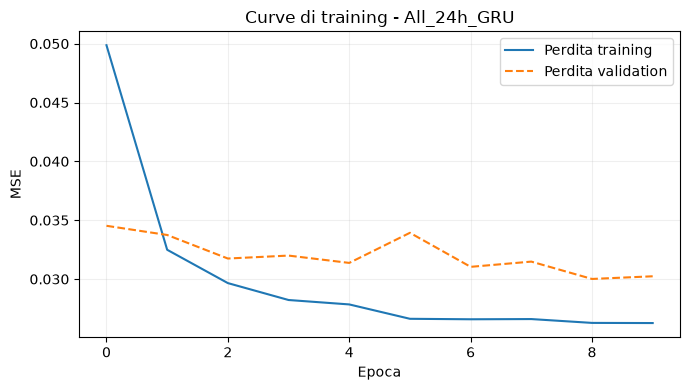

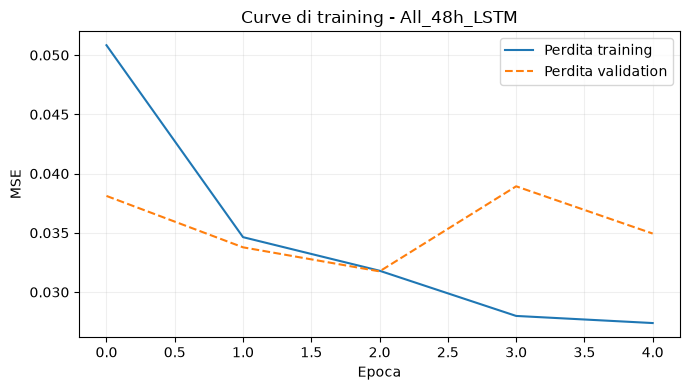

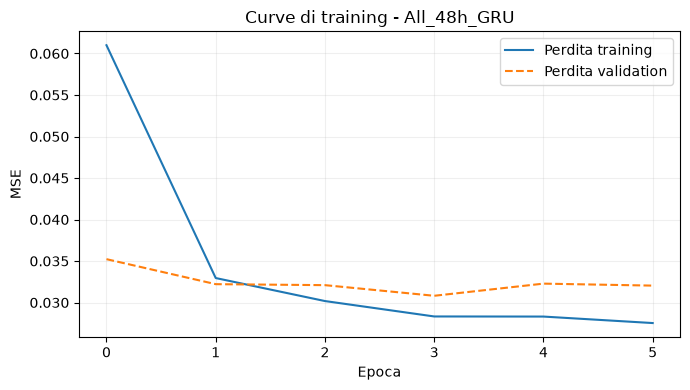

In [10]:
# Curve di training: una figura compatta per esperimento per evitare una tela troppo ampia.
for experiment_name, history in histories.items():
    fig, axis = plt.subplots(figsize=(7, 4))
    axis.plot(history["loss"], label="Perdita training")
    axis.plot(history["val_loss"], label="Perdita validation", linestyle="--")
    axis.set_title(f"Curve di training - {experiment_name}")
    axis.set_xlabel("Epoca")
    axis.set_ylabel("MSE")
    axis.grid(True, alpha=0.2)
    axis.legend()
    fig.tight_layout()
    plt.show()
    plt.close(fig)

## 09 - Valutazione sul test set e baseline

La baseline e separata dal modello ML e usa la produzione osservata 24 ore prima (`t-24h`). Il test resta cronologico e non viene usato per il fit degli scaler.

Modello migliore per RMSE sul test: All_12h_LSTM
Metriche modello: {'MSE': 37469.86328125, 'MAE': 125.57161712646484, 'RMSE': 193.57133899740944}
Metriche baseline: {'MSE': 40613.30345859703, 'MAE': 96.36863444208912, 'RMSE': 201.52742607049055}


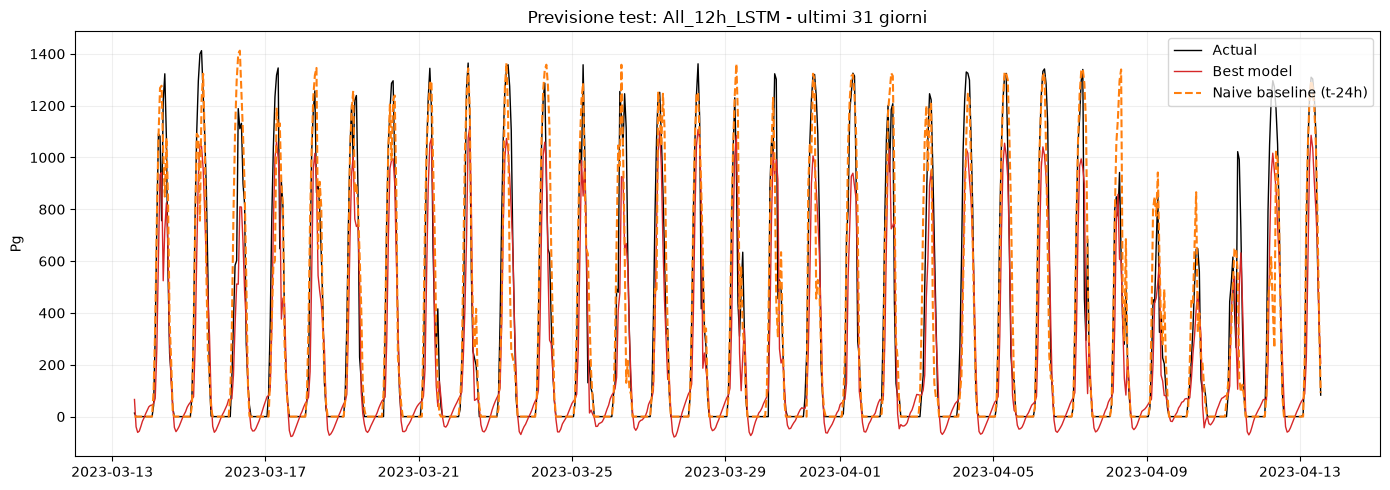

In [11]:
def naive_baseline(frame, target_col, horizon_hours, lag_hours=24):
    """Restituisce la previsione naïve a t−24 ore, allineata all’orizzonte temporale del test finale."""
    return frame[target_col].iloc[-horizon_hours - lag_hours:-lag_hours].to_numpy(dtype="float64")


best_result = results_df.iloc[0]
best_key = f"All_{int(best_result['Seq length (h)'])}h_{best_result['Modello']}"
best_storage = trained_models_storage[best_key]
test_actual = best_storage["y_real"]
test_predicted = best_storage["y_pred"]
test_baseline = naive_baseline(ds_all_full, CONFIG["target_col"], len(test_actual))
baseline_metrics = calculate_metrics(test_actual, test_baseline)
print(f"Modello migliore per RMSE sul test: {best_key}")
print(f"Metriche modello: {calculate_metrics(test_actual, test_predicted)}")
print(f"Metriche baseline: {baseline_metrics}")

# limita la finestra a gli ultimi 31 giorni.
max_plot_hours = 31 * 24
plot_start = max(0, len(test_actual) - max_plot_hours)
plot_index = ds_all_full.index[-len(test_actual):][plot_start:]
plot_actual = test_actual[plot_start:]
plot_predicted = test_predicted[plot_start:]
plot_baseline = test_baseline[plot_start:]

fig, axis = plt.subplots(figsize=(14, 5))
axis.plot(plot_index, plot_actual, label="Actual", color="black", linewidth=1)
axis.plot(plot_index, plot_predicted, label="Best model", color="tab:red", linewidth=1)
axis.plot(plot_index, plot_baseline, label="Naive baseline (t-24h)", color="tab:orange", linestyle="--")
axis.set_title(f"Previsione test: {best_key} - ultimi 31 giorni")
axis.set_ylabel(CONFIG["target_col"])
axis.legend()
axis.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()
plt.close(fig)

In [12]:
## 10 - Valutazione stagionale 'GRU'

SEASONS = {
    "Primavera": (3, 4, 5),
    "Estate": (6, 7, 8),
    "Autunno": (9, 10, 11),
    "Inverno": (12, 1, 2),
}


def get_season_mask(index, season_name, season_year):
    if season_name == "Inverno":
        return (
            ((index.year == season_year) & (index.month == 12))
            | ((index.year == season_year + 1) & index.month.isin([1, 2]))
        )
    return (index.year == season_year) & index.month.isin(SEASONS[season_name])


def train_aligned_season(frame, season_name, config, use_weather):
    """Addestra causalmente prima di una finestra fissa di previsione stagionale."""
    mask = get_season_mask(frame.index, season_name, config["seasonal_year"])
    season_indices = np.flatnonzero(mask)
    time_steps = config["seasonal_time_steps"]
    horizon = config["seasonal_forecast_hours"]
    if len(season_indices) < horizon or season_indices[0] <= time_steps:
        return None

    week_start = season_indices[0]
    week_end = week_start + horizon
    if week_end > len(frame):
        return None

    data = frame.to_numpy(dtype=config["dtype"])
    target_idx = frame.columns.get_loc(config["target_col"])
    feature_indices = (
        [index for index in range(data.shape[1]) if index != target_idx]
        if use_weather else [target_idx]
    )
    scaler_x = MinMaxScaler().fit(data[:week_start, feature_indices])
    scaler_y = MinMaxScaler().fit(data[:week_start, target_idx].reshape(-1, 1))
    all_train_starts = np.arange(0, week_start - time_steps)
    validation_start = int(len(all_train_starts) * (1 - config["validation_ratio"]))
    train_sequence = WindowSequence(
        data, all_train_starts[:validation_start], feature_indices, target_idx,
        scaler_x, scaler_y, time_steps, config["batch_size"]
    )
    validation_sequence = WindowSequence(
        data, all_train_starts[validation_start:], feature_indices, target_idx,
        scaler_x, scaler_y, time_steps, config["batch_size"]
    )
    model = build_model("GRU", (time_steps, len(feature_indices)), config, seasonal=True) 
    model.compile(optimizer="adam", loss="mse")  # fine-tuning/transfer learning del modello GRU addestrato sul dataset completo, usando solo i dati precedenti alla stagione 
    model.fit( # risparmia molto sull'addestramento
        train_sequence,
        validation_data=validation_sequence,
        epochs=config["seasonal_epochs"],
        shuffle=False,
        verbose=0,
        callbacks=[EarlyStopping(
            monitor="val_loss",
            patience=config["seasonal_patience"],
            restore_best_weights=True,
        )],
    )

    forecast_windows = np.asarray([
        scaler_x.transform(data[start - time_steps:start, feature_indices])
        for start in range(week_start, week_end)
    ], dtype=config["dtype"])
    inference_start = time.perf_counter()
    prediction = scaler_y.inverse_transform(
        model.predict(forecast_windows, verbose=0) # predizione della settimana
    ).reshape(-1)
    inference_seconds = time.perf_counter() - inference_start
    actual = frame[config["target_col"]].iloc[week_start:week_end].to_numpy(dtype="float64")
    baseline = frame[config["target_col"]].iloc[week_start - 24:week_end - 24].to_numpy(dtype="float64")
    tf.keras.backend.clear_session()
    return pd.DataFrame(
        {"real": actual, "pred": prediction, "baseline": baseline},
        index=frame.index[week_start:week_end],
    ), inference_seconds


aligned_predictions = {}
for version_name, frame in dataset_versions.items():
    use_weather = "Meteo" in version_name
    for season_name in SEASONS: # addestra un nuovo modello per ogni stagione, usando solo i dati precedenti alla stagione stessa
        seasonal_result = train_aligned_season(frame, season_name, CONFIG, use_weather)
        if seasonal_result is not None:
            aligned_predictions[(version_name, season_name)] = seasonal_result
print(f"Pannelli stagionali generati: {len(aligned_predictions)}/16")

[codecarbon INFO @ 09:44:07] Energy consumed for RAM : 0.001664 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 09:44:07] Energy consumed for all GPUs : 0.002275 kWh. Total GPU Power : 26.001454994424023 W
[codecarbon INFO @ 09:44:07] Delta energy consumed for CPU with cpu_load : 0.000029 kWh, power : 6.858303884900001 W
[codecarbon INFO @ 09:44:07] Energy consumed for All CPU : 0.000611 kWh
[codecarbon INFO @ 09:44:07] 0.004551 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 09:44:22] Energy consumed for RAM : 0.001748 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 09:44:22] Energy consumed for all GPUs : 0.002384 kWh. Total GPU Power : 25.975858357509658 W
[codecarbon INFO @ 09:44:22] Delta energy consumed for CPU with cpu_load : 0.000029 kWh, power : 6.832894732625001 W
[codecarbon INFO @ 09:44:22] Energy consumed for All CPU : 0.000640 kWh
[codecarbon INFO @ 09:44:22] 0.004772 kWh of electricity and 0.000000 L of water were used since the beginni

[codecarbon INFO @ 09:44:52] Energy consumed for RAM : 0.001914 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 09:44:52] Energy consumed for all GPUs : 0.002601 kWh. Total GPU Power : 25.877186899908146 W
[codecarbon INFO @ 09:44:52] Delta energy consumed for CPU with cpu_load : 0.000028 kWh, power : 6.812403444031251 W
[codecarbon INFO @ 09:44:52] Energy consumed for All CPU : 0.000697 kWh
[codecarbon INFO @ 09:44:52] 0.005212 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 09:44:52] 0.004914 g.CO2eq/s mean an estimation of 154.95734149528192 kg.CO2eq/year


[codecarbon INFO @ 09:45:07] Energy consumed for RAM : 0.001997 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 09:45:07] Energy consumed for all GPUs : 0.002708 kWh. Total GPU Power : 25.742912353026252 W
[codecarbon INFO @ 09:45:07] Delta energy consumed for CPU with cpu_load : 0.000029 kWh, power : 6.8902891577 W
[codecarbon INFO @ 09:45:07] Energy consumed for All CPU : 0.000725 kWh
[codecarbon INFO @ 09:45:07] 0.005431 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 09:45:22] Energy consumed for RAM : 0.002081 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 09:45:22] Energy consumed for all GPUs : 0.002816 kWh. Total GPU Power : 25.92738608511297 W
[codecarbon INFO @ 09:45:22] Delta energy consumed for CPU with cpu_load : 0.000030 kWh, power : 7.11372367915625 W
[codecarbon INFO @ 09:45:22] Energy consumed for All CPU : 0.000755 kWh
[codecarbon INFO @ 09:45:22] 0.005652 kWh of electricity and 0.000000 L of water were used since the beginning.
[co

Pannelli stagionali generati: 12/16


,Dataset,Stagione,MAE modello,MAE baseline,RMSE modello,RMSE baseline,Miglioramento RMSE (%),Inferenza (s)
8,Produzione + Meteo - Full,Autunno,144.581,93.586,193.188,181.559,-6.405,0.384
7,Produzione + Meteo - Full,Estate,156.148,95.267,222.984,204.483,-9.048,0.367
9,Produzione + Meteo - Full,Inverno,125.363,80.679,163.480,180.689,9.524,0.368
6,Produzione + Meteo - Full,Primavera,209.039,151.128,332.841,297.293,-11.957,0.335
11,Produzione + Meteo - Meta,Estate,153.370,95.267,212.900,204.483,-4.116,0.340
10,Produzione + Meteo - Meta,Primavera,219.159,151.128,343.356,297.293,-15.494,0.334
2,Produzione - Full,Autunno,115.272,93.586,167.263,181.559,7.874,0.336
1,Produzione - Full,Estate,118.415,95.267,177.998,204.483,12.952,0.342
3,Produzione - Full,Inverno,93.265,80.679,136.101,180.689,24.676,0.325
0,Produzione - Full,Primavera,128.661,151.128,221.000,297.293,25.663,0.392


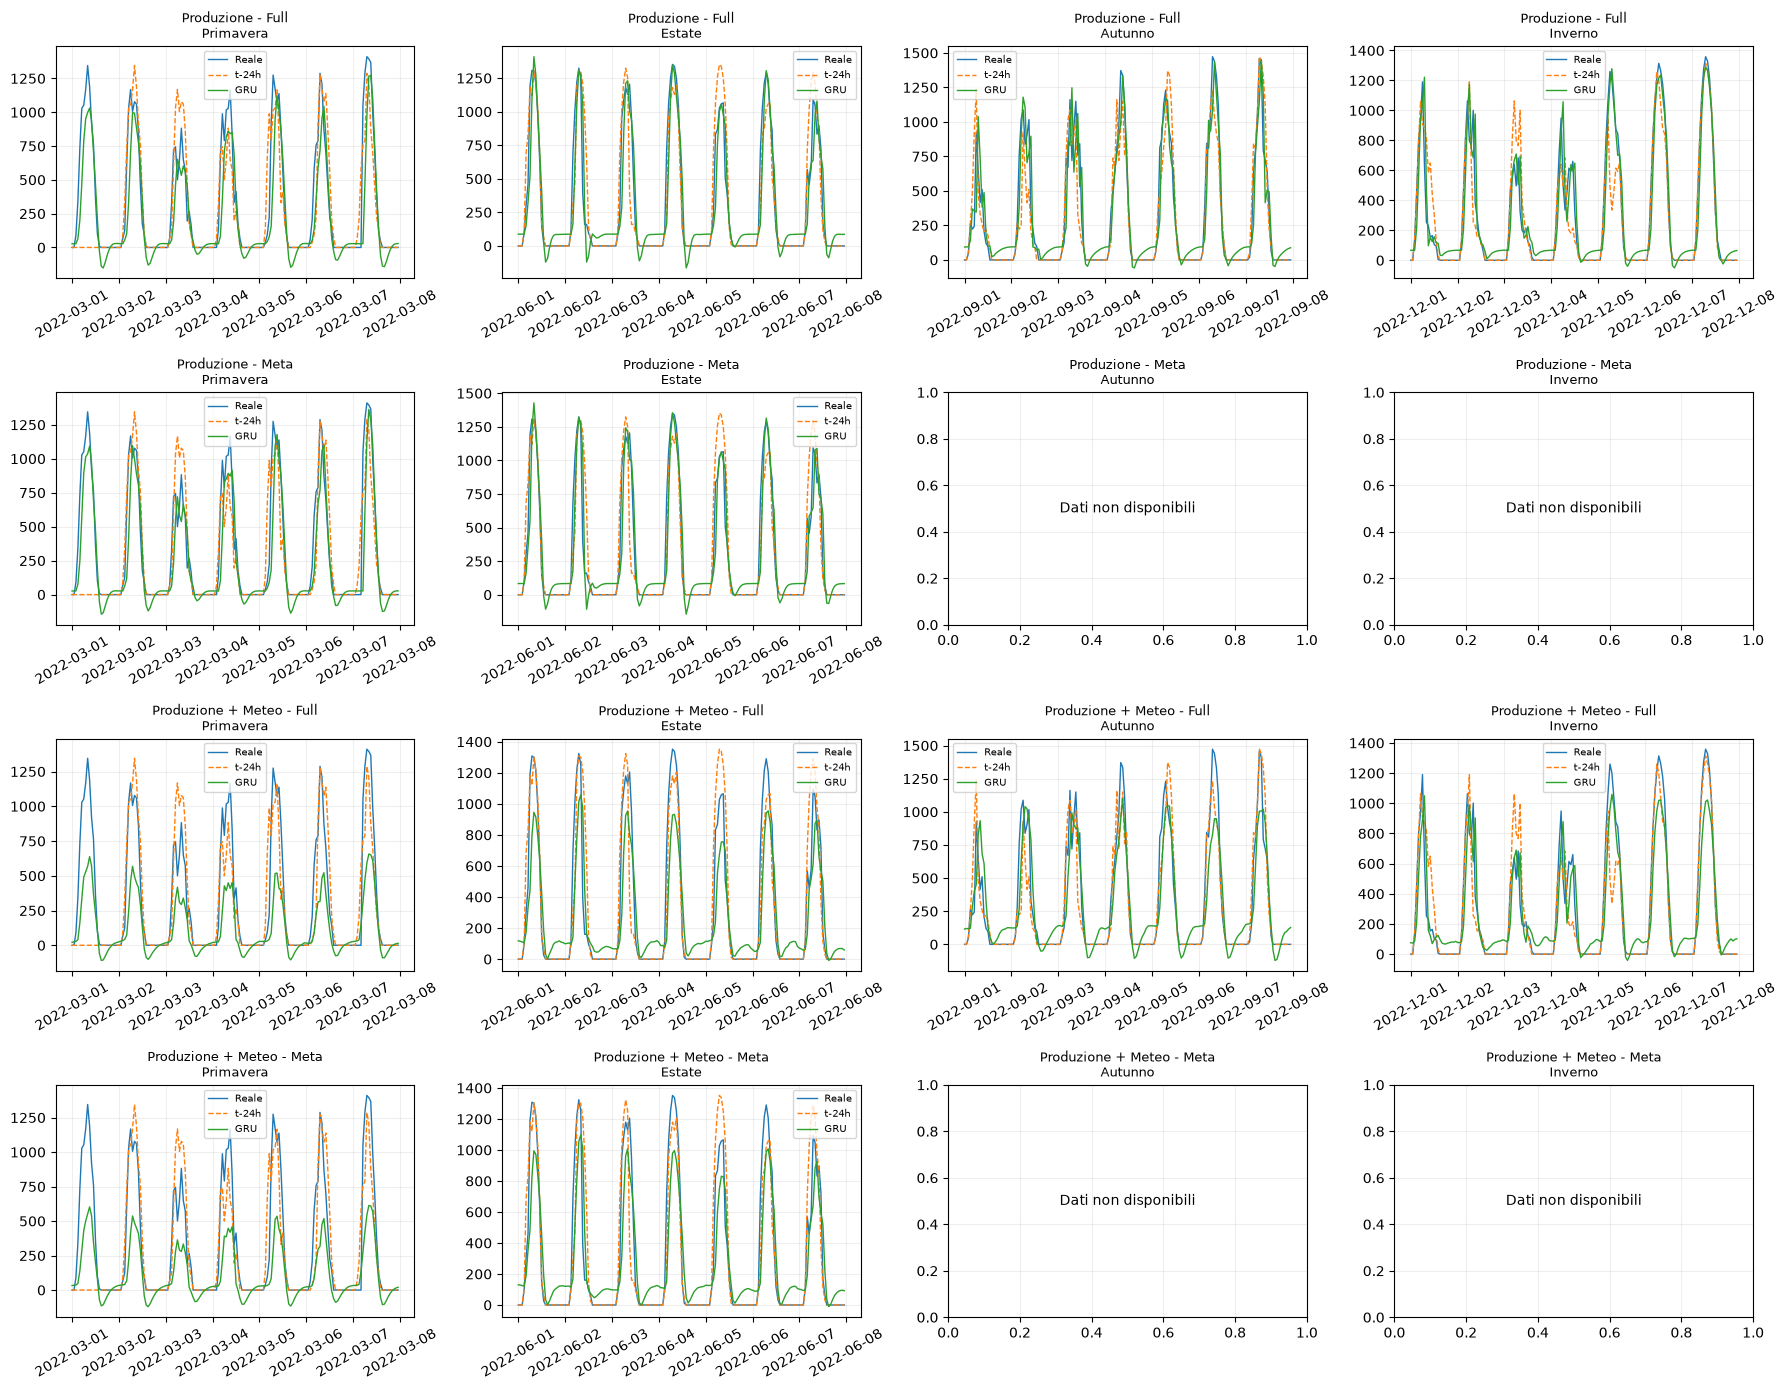

In [13]:
# 11 - Metriche stagionali e confronto visivo compatto

seasonal_metric_rows = []
for (version_name, season_name), (season_data, inference_seconds) in aligned_predictions.items():
    model_metrics = calculate_metrics(season_data["real"], season_data["pred"])
    baseline_metrics = calculate_metrics(season_data["real"], season_data["baseline"])
    baseline_rmse = baseline_metrics["RMSE"]
    seasonal_metric_rows.append({
        "Dataset": version_name,
        "Stagione": season_name,
        "MAE modello": model_metrics["MAE"],
        "MAE baseline": baseline_metrics["MAE"],
        "RMSE modello": model_metrics["RMSE"],
        "RMSE baseline": baseline_rmse,
        "Miglioramento RMSE (%)": (
            (1 - model_metrics["RMSE"] / baseline_rmse) * 100
            if baseline_rmse else np.nan
        ),
        "Inferenza (s)": inference_seconds,
    })

seasonal_metrics = pd.DataFrame(seasonal_metric_rows).sort_values(["Dataset", "Stagione"])
display(seasonal_metrics.round(3))

if aligned_predictions:
    fig, axes = plt.subplots(
        len(dataset_versions), len(SEASONS),
        figsize=(18, max(10, 3.5 * len(dataset_versions))),
        squeeze=False,
    )
    for row, version_name in enumerate(dataset_versions):
        for column, season_name in enumerate(SEASONS):
            axis = axes[row, column]
            result = aligned_predictions.get((version_name, season_name))
            if result is None:
                axis.text(0.5, 0.5, "Dati non disponibili", ha="center", va="center")
            else:
                season_data = result[0]
                axis.plot(season_data.index, season_data["real"], label="Reale", linewidth=1)
                axis.plot(season_data.index, season_data["baseline"], label="t-24h", linestyle="--", linewidth=1)
                axis.plot(season_data.index, season_data["pred"], label="GRU", linewidth=1)
                axis.tick_params(axis="x", rotation=30)
                axis.legend(fontsize=7)
            axis.set_title(f"{version_name}\n{season_name}", fontsize=9)
            axis.grid(True, alpha=0.2)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

### percentuale negativa = peggiore del n% della baseline

### Nota metodologica

Le stagioni sono valutate con uno split causale: per ogni finestra di 168 ore il modello vede soltanto osservazioni precedenti. L'inverno combina dicembre dell'anno configurato con gennaio e febbraio dell'anno successivo.

I dataset `Produzione - Full`, `Produzione - Meta`, `Produzione + Meteo - Full` e `Produzione + Meteo - Meta` usano la stessa funzione di training. I pannelli assenti indicano che la versione `Meta` non contiene quella stagione, non un errore di predizione.

> ### CPU OPTIMIZATION
>
> Il loop parametrico evita di duplicare il preprocessing per LSTM, GRU e lunghezze diverse. Le figure vengono chiuse dopo la visualizzazione per non accumulare memoria.

# Predizione eliminando ore notturne

=================== CONFRONTO SOGLIE GTI ===================
Modello analizzato: All_12h_LSTM
Originale -> RMSE: 193.5713 | MAE: 125.5716
Baseline  -> RMSE: 201.5274 | MAE: 96.3686

 Soglia GTI (W/m²)       RMSE        MAE  Punti Azzerati
               1.0 193.571339 125.571617               0
               2.0 191.651947 110.607697             783
               3.0 191.392982 108.752991             875
               4.0 191.359895 108.515671             886
               5.0 191.359231 108.497360             890
               6.0 191.349760 108.405609             897
               7.0 191.321596 108.242424             905
               8.0 191.299197 108.133255             912
               9.0 191.287394 108.060959             918
              10.0 191.281207 108.016388             921
              11.0 191.284954 108.034576             925
              12.0 191.278848 108.019699             930
              13.0 191.288201 108.077164             934
              14.0 1

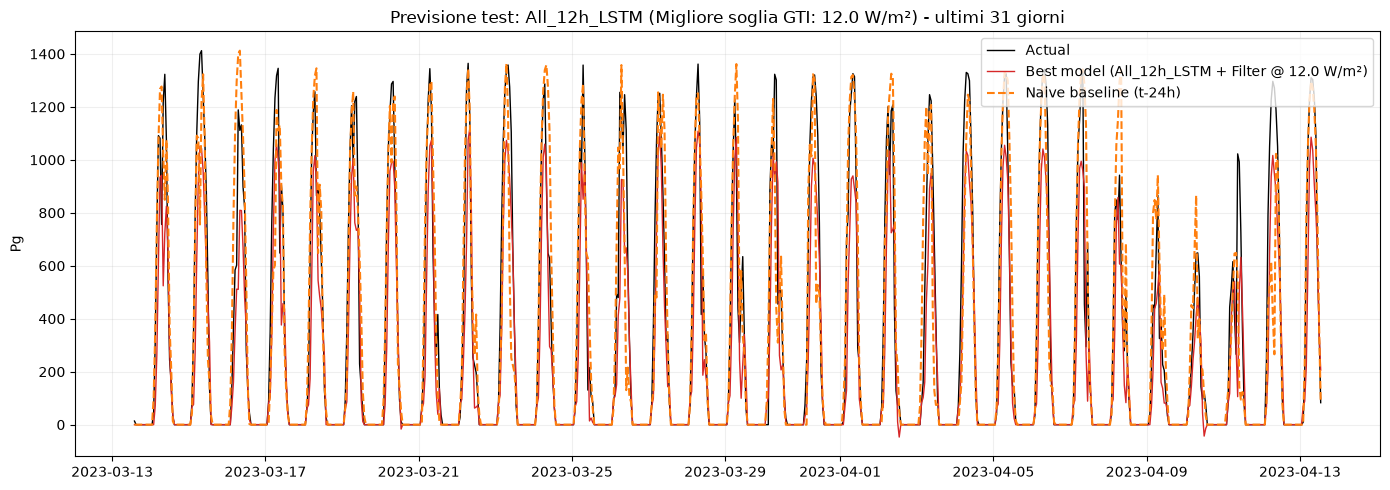

In [14]:
# --- DEFINIZIONE FILTRO NOTTURNO ROBUSTO ---
def apply_robust_night_filter(preds_df, full_dataset=None, gti_col="GTI", gti_threshold=10.0, start_night=21, end_night=5):
    """
    Azzera le predizioni notturne basandosi sulla soglia GTI.
    """
    df_filtered = preds_df.copy()
    
    if full_dataset is not None and gti_col in full_dataset.columns:
        gti_series = full_dataset.loc[df_filtered.index, gti_col]
        sensor_mask = gti_series <= gti_threshold
        hours = df_filtered.index.hour
        time_mask = (hours >= start_night) | (hours < end_night)
        night_mask = np.where(gti_series.notna(), sensor_mask, time_mask)
    else:
        hours = df_filtered.index.hour
        night_mask = (hours >= start_night) | (hours < end_night)

    df_filtered.loc[night_mask, "pred"] = 0.0
    return df_filtered


def naive_baseline(frame, target_col, horizon_hours, lag_hours=24):
    return frame[target_col].iloc[-horizon_hours - lag_hours:-lag_hours].to_numpy(dtype="float64")


# 1. Selezione dinamica del modello migliore
best_result = results_df.iloc[0]
best_key = f"All_{int(best_result['Seq length (h)'])}h_{best_result['Modello']}"
best_storage = trained_models_storage[best_key]

test_actual = best_storage["y_real"]
test_predicted_raw = best_storage["y_pred"]
test_baseline = naive_baseline(ds_all_full, CONFIG["target_col"], len(test_actual))
test_index = ds_all_full.index[-len(test_actual):]

preds_df = pd.DataFrame({"pred": test_predicted_raw}, index=test_index)
raw_metrics = calculate_metrics(test_actual, test_predicted_raw)
baseline_metrics = calculate_metrics(test_actual, test_baseline)

# 2. Ciclo di ricerca della migliore soglia GTI (da 1.0 a 20.0 W/m²)
thresholds = np.arange(1.0, 21.0, 1.0)
grid_results = []

for thresh in thresholds:
    filtered_df = apply_robust_night_filter(
        preds_df, 
        full_dataset=ds_all_full, 
        gti_col="GTI", 
        gti_threshold=thresh
    )
    pred_filt = filtered_df["pred"].to_numpy()
    metrics = calculate_metrics(test_actual, pred_filt)
    
    gti_series = ds_all_full.loc[test_index, "GTI"] if "GTI" in ds_all_full.columns else None
    zero_count = (gti_series <= thresh).sum() if gti_series is not None else 0

    grid_results.append({
        "Soglia GTI (W/m²)": thresh,
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "MSE": metrics["MSE"],
        "Punti Azzerati": zero_count,
        "pred_array": pred_filt
    })

# Visualizzazione tabella comparativa
results_tab = pd.DataFrame(grid_results)

print("=================== CONFRONTO SOGLIE GTI ===================")
print(f"Modello analizzato: {best_key}")
print(f"Originale -> RMSE: {raw_metrics['RMSE']:.4f} | MAE: {raw_metrics['MAE']:.4f}")
print(f"Baseline  -> RMSE: {baseline_metrics['RMSE']:.4f} | MAE: {baseline_metrics['MAE']:.4f}\n")
print(results_tab[["Soglia GTI (W/m²)", "RMSE", "MAE", "Punti Azzerati"]].to_string(index=False))

# 3. Estrazione della configurazione ottimale (minor RMSE)
best_row = results_tab.loc[results_tab["RMSE"].idxmin()]
best_thresh = best_row["Soglia GTI (W/m²)"]
best_predicted = best_row["pred_array"]

print("\n=================== SOGLIA OTTIMALE TROVATA ===================")
print(f"Soglia GTI ideale : {best_thresh:.1f} W/m²")
print(f"RMSE Ottimizzato  : {best_row['RMSE']:.4f} (Guadagno vs Originale: {raw_metrics['RMSE'] - best_row['RMSE']:.4f})")
print(f"MAE Ottimizzato   : {best_row['MAE']:.4f} (Guadagno vs Originale: {raw_metrics['MAE'] - best_row['MAE']:.4f})")

# 4. Grafico solo per la soglia migliore (ultimi 31 giorni)
month_hours = 31 * 24
plot_start = max(0, len(test_actual) - month_hours)

plot_index = test_index[plot_start:]
plot_actual = test_actual[plot_start:]
plot_predicted = best_predicted[plot_start:]
plot_baseline = test_baseline[plot_start:]

fig, axis = plt.subplots(figsize=(14, 5))
axis.plot(plot_index, plot_actual, label="Actual", color="black", linewidth=1)
axis.plot(plot_index, plot_predicted, label=f"Best model ({best_key} + Filter @ {best_thresh:.1f} W/m²)", color="tab:red", linewidth=1)
axis.plot(plot_index, plot_baseline, label="Naive baseline (t-24h)", color="tab:orange", linestyle="--")
axis.set_title(f"Previsione test: {best_key} (Migliore soglia GTI: {best_thresh:.1f} W/m²) - ultimi 31 giorni")
axis.set_ylabel(CONFIG["target_col"])
axis.legend()
axis.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()
plt.close(fig)

### Conclusione: Il modello All_12h_LSTM con filtro notturno a $12\text{ W/m}^2$ è la soluzione migliore in assoluto per la pipeline di previsione.

# Stime economice e Co2 

In [15]:
emissions = tracker.stop()
print(f"Emissions: {emissions} kg CO₂")
# fine registrazione emissioni

[codecarbon INFO @ 09:46:31] Energy consumed for RAM : 0.002460 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 09:46:31] Energy consumed for all GPUs : 0.003324 kWh. Total GPU Power : 26.083158845305864 W
[codecarbon INFO @ 09:46:31] Delta energy consumed for CPU with cpu_load : 0.000016 kWh, power : 6.886514596000001 W
[codecarbon INFO @ 09:46:31] Energy consumed for All CPU : 0.000885 kWh
[codecarbon INFO @ 09:46:31] 0.006670 kWh of electricity and 0.000000 L of water were used since the beginning.


Emissions: 0.0022058941729433154 kg CO₂


### 12 - Stima energetica ed economica semplificata con modello 12h LSTM (con Filtro Notturno Dinamico)

In [17]:
# Definizione della funzione per la conversione da Watt-secondi a kWh
def energy_kwh(duration_seconds, power_w):
    return float(duration_seconds) * float(power_w) / 3_600_000.0

# 0. Parametri da CONFIG con valori di fallback
gti_column = CONFIG.get("gti_col", "GTI")
peak_start = CONFIG.get("autoconsumption_peak_start", 10)
peak_end = CONFIG.get("autoconsumption_peak_end", 14)
rate_peak = CONFIG.get("autoconsumption_rate_peak", 0.80)
rate_offpeak = CONFIG.get("autoconsumption_rate_offpeak", 0.50)

# 1. Recupero dinamico del modello migliore
best_result = results_df.iloc[0]
best_key = f"All_{int(best_result['Seq length (h)'])}h_{best_result['Modello']}"
best_storage = trained_models_storage[best_key]

print(f"## 12 - Stima energetica ed economica per {best_key}")

actual_w = np.asarray(best_storage["y_real"], dtype="float64")
forecast_raw_w = np.maximum(np.asarray(best_storage["y_pred"], dtype="float64"), 0)
baseline_w = np.maximum(naive_baseline(ds_all_full, CONFIG["target_col"], len(actual_w)), 0)
test_index = ds_all_full.index[-len(actual_w):]

# 2. Applicazione del filtro notturno con soglia ottimale
opt_thresh = best_thresh if 'best_thresh' in locals() else 12.0

preds_df = pd.DataFrame({"pred": best_storage["y_pred"]}, index=test_index)
preds_filtered_df = apply_robust_night_filter(
    preds_df,
    full_dataset=ds_all_full,
    gti_col=gti_column,
    gti_threshold=opt_thresh
)
forecast_filtered_w = np.maximum(preds_filtered_df["pred"].to_numpy(dtype="float64"), 0)

# 3. Calcolo dell'autoconsumo
autoconsumption_rate = np.where(
    (test_index.hour >= peak_start) & (test_index.hour <= peak_end), rate_peak, rate_offpeak
)

model_raw_autoconsumed_kwh = float((forecast_raw_w * autoconsumption_rate).sum() / 1000)
model_filt_autoconsumed_kwh = float((forecast_filtered_w * autoconsumption_rate).sum() / 1000)
baseline_autoconsumed_kwh = float((baseline_w * autoconsumption_rate).sum() / 1000)

gross_benefit_raw_eur = (model_raw_autoconsumed_kwh - baseline_autoconsumed_kwh) * CONFIG["energy_price_eur_kwh"]
gross_benefit_filt_eur = (model_filt_autoconsumed_kwh - baseline_autoconsumed_kwh) * CONFIG["energy_price_eur_kwh"]

# 4. Calcoli energetici teorici (Training + Inferenza)
total_training_seconds = float(results_df["Tempo (s)"].sum())

if 'seasonal_metrics' in locals() and isinstance(seasonal_metrics, pd.DataFrame) and not seasonal_metrics.empty:
    inference_seconds = float(seasonal_metrics["Inferenza (s)"].median())
else:
    inference_seconds = float(CONFIG.get("default_inference_seconds", 0.05))

training_energy_kwh_theoretical = energy_kwh(total_training_seconds, CONFIG["training_power_w"])
inference_energy_kwh = energy_kwh(len(actual_w) * inference_seconds, CONFIG["prediction_power_w"])

total_energy_kwh_theoretical = training_energy_kwh_theoretical + inference_energy_kwh
energy_cost_theoretical_eur = total_energy_kwh_theoretical * CONFIG["energy_price_eur_kwh"]

# 5. Estrazione dell'energia di addestramento REALE da CodeCarbon (variabile `emissions`)
real_training_kwh = training_energy_kwh_theoretical  # Fallback al teorico se assente

if 'emissions' in locals():
    if hasattr(emissions, 'energy_consumed'):  # Oggetto EmissionsData di CodeCarbon
        real_training_kwh = float(emissions.energy_consumed)
    elif isinstance(emissions, pd.DataFrame) and 'energy_consumed' in emissions.columns:  # DataFrame CodeCarbon
        real_training_kwh = float(emissions['energy_consumed'].sum())
    elif isinstance(emissions, dict) and 'energy_consumed' in emissions:
        real_training_kwh = float(emissions['energy_consumed'])
    elif isinstance(emissions, (int, float)):  # Valore numerico float/int diretto
        real_training_kwh = float(emissions)

total_energy_kwh_real = real_training_kwh + inference_energy_kwh
energy_cost_real_eur = total_energy_kwh_real * CONFIG["energy_price_eur_kwh"]

# 6. Tabella riassuntiva a 3 righe (Teorico Originale vs Teorico Filtrato vs CodeCarbon Reale)
energy_summary = pd.DataFrame([
    {
        "Modello": f"{best_key} (Teorico Originale)",
        "Training totale (h)": total_training_seconds / 3600,
        "Energia totale (kWh)": total_energy_kwh_theoretical,
        "Autoconsumo modello (kWh)": model_raw_autoconsumed_kwh,
        "Autoconsumo baseline (kWh)": baseline_autoconsumed_kwh,
        "Guadagno lordo stimato (EUR)": gross_benefit_raw_eur,
        "Costo energia stimato (EUR)": energy_cost_theoretical_eur,
        "Guadagno netto stimato (EUR)": gross_benefit_raw_eur - energy_cost_theoretical_eur,
    },
    {
        "Modello": f"{best_key} + Filtro ({opt_thresh:.1f} W/m² - Teorico)",
        "Training totale (h)": total_training_seconds / 3600,
        "Energia totale (kWh)": total_energy_kwh_theoretical,
        "Autoconsumo modello (kWh)": model_filt_autoconsumed_kwh,
        "Autoconsumo baseline (kWh)": baseline_autoconsumed_kwh,
        "Guadagno lordo stimato (EUR)": gross_benefit_filt_eur,
        "Costo energia stimato (EUR)": energy_cost_theoretical_eur,
        "Guadagno netto stimato (EUR)": gross_benefit_filt_eur - energy_cost_theoretical_eur,
    },
    {
        "Modello": f"{best_key} + Filtro ({opt_thresh:.1f} W/m² - CodeCarbon Reale)",
        "Training totale (h)": total_training_seconds / 3600,
        "Energia totale (kWh)": total_energy_kwh_real,
        "Autoconsumo modello (kWh)": model_filt_autoconsumed_kwh,
        "Autoconsumo baseline (kWh)": baseline_autoconsumed_kwh,
        "Guadagno lordo stimato (EUR)": gross_benefit_filt_eur,
        "Costo energia stimato (EUR)": energy_cost_real_eur,
        "Guadagno netto stimato (EUR)": gross_benefit_filt_eur - energy_cost_real_eur,
    }
])

display(energy_summary.round(3))

## 12 - Stima energetica ed economica per All_12h_LSTM


,Modello,Training totale (h),Energia totale (kWh),Autoconsumo modello (kWh),Autoconsumo baseline (kWh),Guadagno lordo stimato (EUR),Costo energia stimato (EUR),Guadagno netto stimato (EUR)
0,All_12h_LSTM (Teorico Originale),0.058,0.010,250.325,329.936,-19.903,0.003,-19.905
1,All_12h_LSTM + Filtro (12.0 W/m² - Teorico),0.058,0.010,241.251,329.936,-22.171,0.003,-22.174
2,All_12h_LSTM + Filtro (12.0 W/m² - CodeCarbon ...,0.058,0.008,241.251,329.936,-22.171,0.002,-22.173


In [18]:
print(f"Inizio Test Set: {test_index[0]}")
print(f"Fine Test Set:   {test_index[-1]}")
print(f"Durata totale:   {test_index[-1] - test_index[0]}")

Inizio Test Set: 2023-01-23 18:00:00+00:00
Fine Test Set:   2023-04-13 13:00:00+00:00
Durata totale:   79 days 19:00:00


## 13 - Interpretazione e limiti

La stima energetica ed economica semplificata: usa le potenze configurate, il tempo misurato di inferenza, un prezzo fisso e un'autoconsumo assunto pari all'80% tra le 10:00 e le 14:00 e al 50% nelle altre ore. Non rappresenta il costo reale dell'infrastruttura e non include hardware, raffreddamento, accumulo, tariffe o variazioni del prezzo.

### 14 - disclaimer sull'utilizzo di strumenti di Intelligenza Artificiale
Nello sviluppo del presente progetto sono stati impiegati strumenti di Intelligenza Artificiale (AI) esclusivamente come supporto alle attività di sviluppo, revisione e ottimizzazione del codice. In particolare, l'utilizzo di tali strumenti ha riguardato principalmente attività di refactoring del codice originale, con l'obiettivo di migliorarne la leggibilità, la modularità e l'efficienza computazionale, nonché interventi di ottimizzazione dell'utilizzo della memoria RAM.

Le ottimizzazioni relative alla gestione della memoria sono state rese necessarie dalle limitazioni di memoria riscontrate durante l'esecuzione del progetto nell'ambiente Google Colab. Tali limitazioni hanno richiesto una revisione delle strategie di gestione dei dati e delle risorse computazionali e, successivamente, il trasferimento dell'esecuzione del progetto a un ambiente locale.

Il codice eventualmente generato o modificato mediante strumenti AI non è da considerarsi integralmente prodotto dall'AI, ma è stato sottoposto a revisione, verifica e adattamento rispetto alle specifiche esigenze del progetto. Le scelte progettuali, metodologiche e interpretative, così come la valutazione della correttezza e dell'adeguatezza delle modifiche introdotte, rimangono sotto la responsabilità dell'autore del progetto.

L'impiego di strumenti AI è pertanto da intendersi come strumento ausiliario al processo di sviluppo, senza sostituire le attività di analisi, comprensione, verifica e validazione richieste nell'ambito del progetto universitario.

### precisazioni:

Stima economica:

12h LSTM

------------------------

Analisi stagionale:

Primavera | GRU 24h
Estate    | GRU 24h
Autunno   | GRU 24h
Inverno   | GRU 24h

per risparmiare tempo